# 🧑🏼‍💻Laptop_chatbot Demo 🧑🏾‍💻

### __________________________________________________________________________________________________
## Objectives 
- make a chatbot like  the last one but with langraph
- Ensure the AI provides parameters to the tool, calls the tool function, and retrieves the results.
- learn all you can so that you can use it for the upcoming PC part picker project
### __________________________________________________________________________________________________
## Note: AI handles its strengths; all other tasks are handled by functions.
-Ai input and output is controlled
    -For example, if the AI wants to use the `attribute_search` tool, it only needs to call the tool and supply the attribute value and keyword. Otherwise, the tool will return an error (same applies to output).
    - Optionally, an MCP server can be used. 
- controlled sql querys
- controlled tool use
- controlled api calls
- controlled function calls
- Let the llm only act as a brain; build  the "nervious system" and "body" around that brain.
### __________________________________________________________________________________________________


## Installing the required Libraries 
we start by installing and importing the LangGraph SDK and LangChain support for the Gemini API.

In [1]:
# i will find something for that error message sha 
# Hiding warnings
import warnings
warnings.filterwarnings("ignore")

# Remove conflicting packages from the Kaggle base environment.
!pip uninstall -qqy  jupyterlab libpysal thinc spacy fastai ydata-profiling google-cloud-bigquery google-generativeai
# Install langgraph and the packages used in this lab.
!pip install -qU 'langgraph==0.3.21' 'langchain-google-genai==2.1.2' 'langgraph-prebuilt==0.1.7'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.0/444.0 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.5/378.5 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 73.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.12 requires async-ti

- I Still don't know how to get rid of this dependecies error (if you do please comment )

## Importing the required Libraries 

In [2]:
from google import genai
from google.genai import types

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split # Split data into train data and test data
from sklearn.metrics import r2_score, mean_squared_error # Metrics for Regression Analysis
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

### Adding my Google Api Key to The Notebook 

>**Note**:
> you cant run the Gemini Ai without adding your google Generative api key get one [here](https://ai.google.dev/?gemini-api/docs/api-key).<br>
>Keep your API key a secret.(if your are runiing it locally use ".dotennv").

In [3]:
import os
from kaggle_secrets import UserSecretsClient

GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

### Defining the Core Instructions 
- setting the state and instructions along with the welcome massage  

In [4]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    """State representing the customer's Laptop conversation."""

    # The chat conversation. This preserves the conversation history
    # between nodes. The `add_messages` annotation indicates to LangGraph
    # that state is updated by appending returned messages, not replacing
    # them.
    messages: Annotated[list, add_messages]

    # The customer's specifics of laptop.
    chat: list[str]

    # This Flag helps end the conversation with the llm
    finished: bool
    # This Flag helps indicate to the human node that the tool is in use 
    tool_in_use: bool

laptop_chatbot = (
    "system",
    "You are a helpful, knowledgeable, and friendly Laptop Sales Assistant. "
    "Your goal is to help users find the best laptops based on their needs, preferences, and budget. "
    "You have access to an SQL database containing laptop specifications, prices, and descriptions, "
    "as well as three tools to assist your searches: "
    "`attribute_search` (search laptops by a specific column and value), "
    "`specific_search` (search laptops by a keyword in brand, description, or processor), "
    "and `range_search` (search laptops by numeric attributes within a specified range). "
    "Use these tools and the database to give accurate, helpful recommendations.\n\n"
    "Always ask clarifying questions if the user's request is vague or missing important details "
    "(e.g., budget, intended use, preferred brands, etc.). "
    "Provide concise, clear advice that balances performance and value for money. "
    "If multiple laptops match the request, suggest the top 2–3 options with brief explanations. "
    "Do not make up data—rely only on the information provided via the SQL database or tools. "
    "If no match is found, kindly inform the user and suggest alternatives. "
    "Respond in a warm and helpful tone, like a tech-savvy friend who wants the best for the user."
)


Welcome_msg = "Hello, What can i do for you" # just for now i will change it later 

## Define the sql_search_tools 
- Define the tools that the AI can call.
- One problem: the tool retrieves too many rows, causing a major overload.
- Current solution: limit the SQL query to return only 10 rows instead of 500–1000.
- There may be better ways to handle this; further research is needed.

### About the Tools

`pydantic` is used for tool validation.  
The tools are then bound to the chatbot (hence why they are defined first).

There are three tools:

#### 1. Attribute_search tool
- Searches laptops where a specific column (attribute) matches a given value.  
- Arguments:
  - `attribute`: the column in the database to search (e.g., Brand or Price)  
  - `value`: the value to search for in the column (e.g., under Brand – Dell or Acer)  

#### 2. Specific_search tool
- Searches for a laptop by brand, product description, or processor containing the keyword.  
- Arguments:
  - `keyword`: the specific term to search for  

#### 3. Range_search tool
- Searches for laptops where a numeric attribute falls within a specified range.  
- Arguments:
  - `attribute`: the column in the database to search  
  - `min_value`: the minimum value in the range  
  - `max_value`: the maximum value in the range  


    

In [5]:
from pydantic import BaseModel, Field


# Search by a common attribute 
class Attribute_search(BaseModel):
    attribute: str = Field(description = "column of the database to search")
    value: object = Field(description = "the value to search for " )


def attribute_search(attribute: str, value: object)-> dict:
    """
    Search laptops where a specific column matches a given value.
    Example: search_by_attribute("Brand", "Dell")
    """
    ALLOWED_COLUMNS = {"id", "Brand", "Product_Description", "Screen_Size", "RAM", "Processor",
                       "GPU", "GPU_Type", "Resolution", "Condition", "Price", "SSD", "HDD"}
    if attribute not in ALLOWED_COLUMNS:
        raise ValueError("Invalid attribute name")

    query = f"SELECT * FROM Laptop WHERE {attribute} = ? LIMIT 10"
    cursor.execute(query, (value,))
    return cursor.fetchall()


#  Search for a specific laptop (by name or description)
class SpecificSearch(BaseModel):
    keyword: object = Field(description = "specific keyword to search for on the database ")



def search_specific_laptop(keyword: object)-> dict:
    """
    Search for a laptop by brand, product description, or processor containing the keyword.
    Example: search_specific_laptop("MacBook")
    """
    query = """
    SELECT * FROM Laptop
    WHERE Brand LIKE ? OR Product_Description LIKE ? OR Processor LIKE ? OR Screen_Size LIKE ? OR RAM LIKE ? OR GPU LIKE ? OR GPU_Type LIKE ? OR Condition Like ? LIMIT 10
    """
    keyword = f"%{keyword}%"  # Partial match
    cursor.execute(query, (keyword, keyword, keyword, keyword, keyword, keyword, keyword, keyword))
    return cursor.fetchall()


#  Search by range of common attributes
class RangeSearch(BaseModel):
    attribute: str = Field(description = "column in the database which will be searched using range of min - max")
    min_value: int = Field(description = "the minimum value in the range of search")
    max_value: int = Field(description = "the maximum value in the range of search")



def search_by_range(attribute: str, min_value: int, max_value: int)-> dict:
    """
    Search Laptop where a numeric attribute falls between two values.
    Example: search_by_range("Price", 500, 1000)
    """
    query = f"SELECT * FROM Laptop WHERE {attribute} BETWEEN ? AND ? LIMIT 10"
    cursor.execute(query, (min_value, max_value))
    return cursor.fetchall()


In [6]:
from langchain_core.tools import tool

@tool(args_schema=Attribute_search)
def get_attribute_search_tool(attribute: str, value: object) -> dict:
    """
    Search laptops where a specific column matches a given value.
    Example: search_by_attribute("Brand", "Dell")
    """
    return attribute_search(attribute, value)

@tool(args_schema= SpecificSearch)
def get_specific_search_tool(keyword: object)-> dict:
    """
    Search for a laptop by brand, product description, or processor containing the keyword.
    Example: search_specific_laptop("MacBook")
    """
    return search_specific_laptop(keyword)


@tool(args_schema= RangeSearch)
def get_range_search_tool(attribute: str, min_value: int, max_value: int)-> dict:
    """
    Search Laptop where a numeric attribute falls between two values.
    Example: search_by_range("Price", 500, 1000)
    """
    return search_by_range(attribute, min_value, max_value)

## Define your chatbot 
- This is your first node (the chatbot )
- from what i understand the first node is wrapping the gemini Chatbot 

In [7]:
import json

from langgraph.graph import StateGraph, END
from typing import TypedDict, List

from langchain_core.tools import tool
from langchain_core.messages import ToolMessage
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

tools = [get_attribute_search_tool, get_specific_search_tool, get_range_search_tool]


def chatbot_with_welcome_msg(state: ChatState) -> ChatState:
    """The chatbot itself. A wrapper around the model's own chat interface."""
    llm_with_tools = llm.bind_tools(tools)
    
    if state["messages"]:
        # If there are messages, continue the conversation with the Gemini model.
        new_output = llm_with_tools.invoke([laptop_chatbot] + state["messages"])
    else:
        # If there are no messages, start with the welcome message.
        new_output = AIMessage(content=Welcome_msg)

    return state | {"messages": [new_output]}


## Adding a Human Node 
- that is a node in which the human will use for conversation with the model

In [8]:
from langchain_core.messages.ai import AIMessage
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

# this function works on the instance of flags 
# the tool_in_use flag is used to check if the model is calling the tools if so then the user is not asked for input
def human_node(state: ChatState) -> ChatState:
    last_msg = state["messages"][-1]

    # 🚨 If a tool just ran, skip asking the user
    # This uses the defualt - false trick 
    """state.get("tool_in_use", False) means:
    
    “Look up the key "tool_in_use" in state.
    If it exists, return its value.
    If it doesn’t exist, fall back to False.”
    """
    if state.get("tool_in_use", False):
        state["tool_in_use"] = False  # reset for next turn
        return state  # don’t ask user, just continue to model

    print("Model:", last_msg.content)
    user_input = input("User: ")

    # this uses the finished flag to quit the chat when the user inputs ("q","quit", "exit")
    if user_input in {"q", "quit", "exit"}:
        state["finished"] = True

    return state | {"messages": [("user", user_input)]}


In [9]:
from pprint import pprint
from typing import Literal
from IPython.display import Image, display

# this function is used to add a conditional edge to the human node for exiting 
def maybe_exit_human_node(state: ChatState) -> Literal["chatbot", "__end__"]:
    """Route to the chatbot, unless it looks like the user is exiting."""
    if state.get("finished", False):
        return END
    else:
        return "chatbot"

## Setting Up the SQL Database

- The purpose of this section is to demonstrate that the data is pulled from a database, so the database is set up within the same notebook.  
- First, the dataset is imported and processed before being loaded into the database.


### Importing the data 

In [10]:
df = pd.read_csv('/kaggle/input/laptop-price-dataset-april-2024/cleaned.csv')
#Checking the dataset
df.head(1)

,Brand,Product_Description,Screen_Size,RAM,Processor,GPU,GPU_Type,Resolution,Condition,Price
0,Lenovo,Lenovo ThinkPad 14” HD Laptop PC Computer Core...,14.0,16,Intel Core i5 7th Gen.,Intel HD Graphics 520,Integrated/On-Board Graphics,NaN,Very Good - Refurbished,189.99


## Processing the Data

- The dataset is cleaned and prepared before being loaded into the database.  
- Steps for processing the data:
  1. **Load the dataset**: Import the raw dataset into the notebook.  
  2. **Clean the data**: Handle missing values, correct data types, and remove any inconsistencies.  
  3. **Feature engineering**: Create new columns or transform existing ones to make the data more suitable for searching and filtering (e.g., standardizing brand names, extracting numeric values from price columns).  
  4. **Verify the processed data**: Check a few rows to ensure that the cleaning and feature engineering were applied correctly.  
  5. **Prepare for database insertion**: Format the data so it can be inserted into the SQL database without errors. 

In [11]:
def clean_dataset(df):
    imputer = SimpleImputer(strategy='most_frequent').set_output(transform="pandas")
    df[["Resolution","GPU_Type", "GPU"]] = imputer.fit_transform(df[["Resolution","GPU_Type","GPU"]])

    def extract_numbers(text):
        nums = re.findall(r'\d+(?:\.\d+)?', text)  # Regular expression to find numbers
        if nums:
            return int(nums[0])  # Return the first number as a integer
        else:
            return None  # Return None if no number is found
        df["RAM"] = df[["RAM"]].map(extract_numbers)

    df["GPU_Type"] = df["GPU_Type"].apply(lambda x: "Integrated/On-Board Graphics" if x != "Dedicated Graphics" else x)

    def extract_storage(text):
        """
        Extract information about storage capacity from product description.
        """
        SSD_pattern = r"(\d+\.?\d*)\s*(TB|GB)\s*(SSD)"
        HDD_pattern = r"(\d+\.?\d*)\s*(TB|GB)\s*(HDD)"
        return re.findall(SSD_pattern, text), re.findall(HDD_pattern, text)
    
    # Making of storage column from product description column
    storage_df = df["Product_Description"].apply(extract_storage)
    def apply_column(df, list: str ):
        """This function checks if the storage is an HDD or an SSD"""
        for i in list:
            df[i] = storage_df.apply(lambda x: " ".join(x[0][0]) if x[0] != [] else '0')
    list_to_apply = ["SSD", "HDD"]
    apply_column(df,list_to_apply)
    # df["SSD"] = storage_df.apply(lambda x: " ".join(x[0][0]) if x[0] != [] else '0')
    # df["HDD"] = storage_df.apply(lambda x: " ".join(x[1][0]) if x[1] != [] else '0')
    def add_gb_to_storage(df,list: str):
        for i in list:
            df[i] = df[i].str.replace("TB","000 GB").str.findall("\d").apply(lambda x: "".join(x)).astype("int64")

    list_to_add_gb = ["SSD", "HDD"]
    add_gb_to_storage(df, list_to_add_gb)
    # df["SSD"] = df["SSD"].str.replace("TB","000 GB").str.findall("\d").apply(lambda x: "".join(x)).astype("int64")
    # df["HDD"] = df["HDD"].str.replace("TB","000 GB").str.findall("\d").apply(lambda x: "".join(x)).astype("int64")
    df["SSD"].unique(), df["HDD"].unique()

    df.loc[(df["SSD"] == 15000)]
    df["SSD"] = df["SSD"].replace(15000,256)


    num_cols = df.select_dtypes(include=["float","int"]).columns
    imputer = KNNImputer(n_neighbors=2).set_output(transform="pandas")
    df[num_cols] = imputer.fit_transform(df[num_cols])

    return df

df = clean_dataset(df)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2952 entries, 0 to 2951
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                2952 non-null   object 
 1   Product_Description  2952 non-null   object 
 2   Screen_Size          2952 non-null   float64
 3   RAM                  2952 non-null   object 
 4   Processor            2952 non-null   object 
 5   GPU                  2952 non-null   object 
 6   GPU_Type             2952 non-null   object 
 7   Resolution           2952 non-null   object 
 8   Condition            2952 non-null   object 
 9   Price                2952 non-null   float64
 10  SSD                  2952 non-null   float64
 11  HDD                  2952 non-null   float64
dtypes: float64(4), object(8)
memory usage: 276.9+ KB


None

# Setting Up the SQL Database

- `sqlite3` is used as the database because it is lightweight and easy to use, especially within a Kaggle notebook.  
- Steps for setting up the database:
  1. **Initialize the database**: Create a new SQLite database file (or connect to an existing one).  
  2. **Create tables**: Define the schema for the tables based on the dataset columns.  
  3. **Insert data**: Load the processed dataset and insert the rows into the database tables.  
  4. **Verify data**: Optionally, query the database to ensure the data was correctly added.  


In [12]:
#Loading the sql extension into the notebook and creating the laptop_sales database
%load_ext sql
%sql sqlite:///laptop_sales.db

import sqlite3

# Connecting to the created laptop_sales database
conn = sqlite3.connect("laptop_sales.db", check_same_thread=False)
cursor = conn.cursor()


#Creating a table for the columns in the laptop_price dataset
cursor.execute("""
CREATE TABLE IF NOT EXISTS Laptop (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    Brand TEXT,
    Product_Description TEXT,
    Screen_Size TEXT,
    RAM FLOAT, 
    Processor TEXT,
    GPU TEXT,
    GPU_Type TEXT,
    Resolution TEXT,
    Condition TEXT,
    Price FLOAT,
    SSD INTEGER,
    HDD INTEGER
)
""")

# Insert the laptop_sales data into the sql database
for _, row in df.iterrows():
    cursor.execute("INSERT INTO Laptop (Brand, Product_Description, Screen_Size, RAM, Processor, GPU, GPU_Type, Resolution, Condition, Price, SSD, HDD) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)", 
                   (row['Brand'], row['Product_Description'], row['Screen_Size'], row['RAM'], row['Processor'], row['GPU'], row['GPU_Type'], row['Resolution'], row['Condition'], row['Price'], row['SSD'], row['HDD']))

conn.commit()

## Setting Up the Tool Node

This section sets up the function that runs when a tool is called by the AI (tool calls).

- Steps for setting up the tool node:
  1. **Define tool functions**: Implement each tool that the AI can call, such as `attribute_search`, `specific_search`, and `range_search`.  
  2. **Implement `route_tools`**: This function checks whether the AI has made a tool call in its output.  
  3. **Route the call**: If a tool call is detected, `route_tools` forwards the call to the corresponding tool function with the parameters provided by the AI.  
  4. **Return the result**: The tool function executes its logic and returns the results back to the AI, which can then continue the conversation.  
  5. **Error handling**: If the AI provides incorrect parameters or calls a tool incorrectly, the system returns an error message to prevent failures.  

In [13]:
class BasicToolNode():
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        tool_outputs = []
        
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            tool_outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
               )
            # Convert tool result into an AIMessage instead of ToolMessage
            # tool_outputs.append(
            #     AIMessage(
            #         content=f"Here are the results from **{tool_call['name']}**:\n{json.dumps(tool_result, indent=2)}"
            #     )
            #)
        # return {"messages": state["messages"] + tool_outputs}
        return {"messages": tool_outputs}


def route_tools(
    state: ChatState,
):
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        
        if not ai_message.content:
            ai_message.content = "⏳ Let me check the database for you, please wait..."
        state["tool_in_use"] = True 
        return "tools"
    return END

## Compiling the Workflow

This section compiles all the nodes and edges, linking the various parts of the AI agent.

- **Add all nodes**: Include `chatbot_with_msg`, `human_node`, and `tool_node`.  
- **Add edges**: Connect the nodes, including the edges to the tool node, to define the flow of interaction.  
- **Preview the workflow**: Use the `draw_mermaid_png` function to visualize the graph and ensure the nodes and edges are connected correctly.


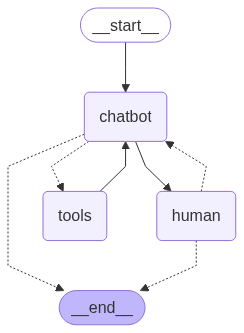

In [14]:
# Start building a new graph.
graph_builder = StateGraph(ChatState)

tool_node = BasicToolNode(tools=tools)
# Add the chatbot and human nodes to the app graph.
graph_builder.add_node("chatbot", chatbot_with_welcome_msg)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)

# Start with the chatbot again.
graph_builder.add_edge(START, "chatbot")

# The chatbot will always go to the human next.
graph_builder.add_edge("chatbot", "human");
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    # The following dictionary lets you tell the graph to interpret the condition's outputs as a specific node
    # It defaults to the identity function, but if you
    # want to use a node named something else apart from "tools",
    # You can update the value of the dictionary to something else
    # e.g., "tools": "my_tools"
    {"tools": "tools", END: END},
)
graph_builder.add_edge("tools", "chatbot")

# add the conditional edge to the maybe exit human node under here

graph_builder.add_conditional_edges("human", maybe_exit_human_node)

chat_with_human_graph = graph_builder.compile()

Image(chat_with_human_graph.get_graph().draw_mermaid_png())

## Note: Interactive Chatbot

This notebook features a **text-based chatbot interface** that uses the `invoke` function for real-time user interaction.


In [15]:
# The default recursion limit for traversing nodes is 25 - setting it higher means
# you can try a more complex order with multiple steps and round-trips (and you
# can chat for longer!)
# config = {"recursion_limit": 100}

# Remember that this will loop forever, unless you input `q`, `quit` or one of the
# other exit terms defined in `human_node`.
# Uncomment this line to execute the graph:
# state = chat_with_human_graph.invoke({"messages": []}, config)

# Things to try:
#  - Just chat! There's no ordering or menu yet.
#  - 'q' to exit.

# pprint(state)